In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [51]:
df=pd.read_csv('/content/breast_cancer_bd.csv')

In [52]:
df.sample(5)

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
584,1217717,5,1,1,6,3,1,1,1,1,2
411,1238464,1,1,1,1,1,?,2,1,1,2
585,1239420,1,1,1,1,2,1,1,1,1,2
425,1258549,9,10,10,10,10,10,10,10,1,4
479,1299161,4,8,7,10,4,10,7,5,1,4


In [53]:
df.nunique()

,0
Sample code number,645
Clump Thickness,10
Uniformity of Cell Size,10
Uniformity of Cell Shape,10
Marginal Adhesion,10
Single Epithelial Cell Size,10
Bare Nuclei,11
Bland Chromatin,10
Normal Nucleoli,10
Mitoses,9


In [54]:
df.isnull().sum()

,0
Sample code number,0
Clump Thickness,0
Uniformity of Cell Size,0
Uniformity of Cell Shape,0
Marginal Adhesion,0
Single Epithelial Cell Size,0
Bare Nuclei,0
Bland Chromatin,0
Normal Nucleoli,0
Mitoses,0


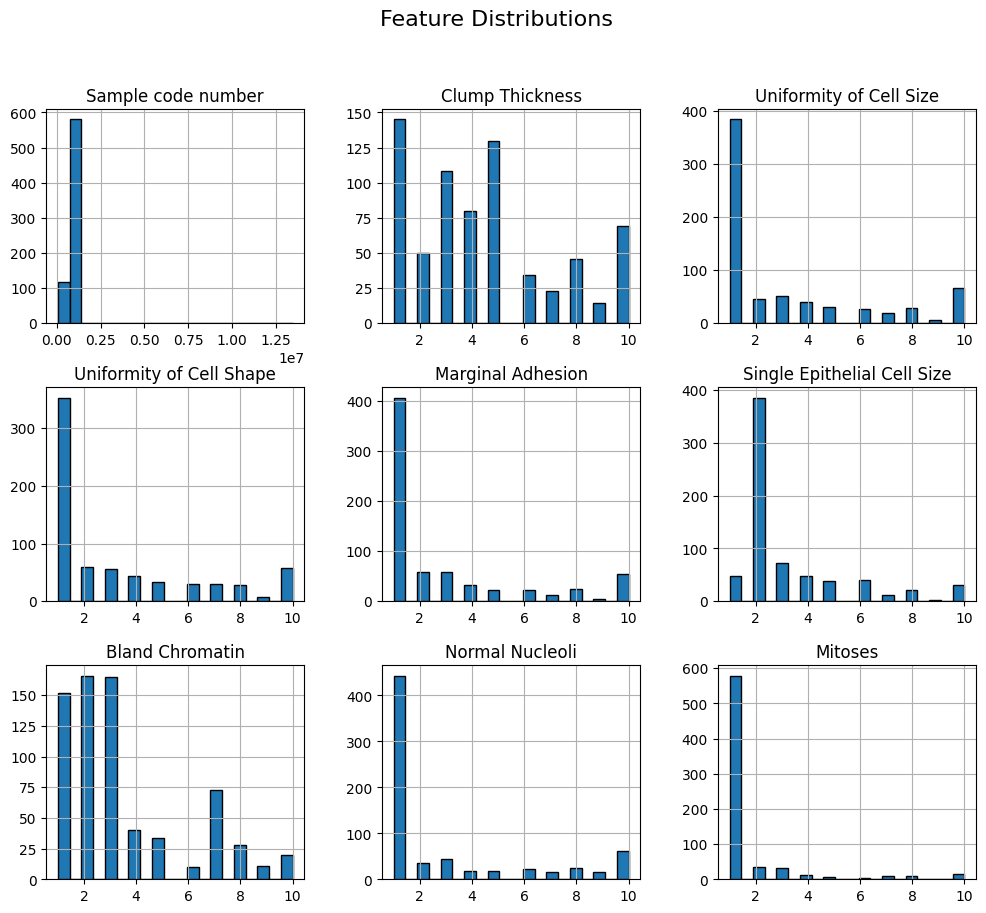

In [55]:
df.drop(columns=['Class']).hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Sample code number           699 non-null    int64 
 1   Clump Thickness              699 non-null    int64 
 2   Uniformity of Cell Size      699 non-null    int64 
 3   Uniformity of Cell Shape     699 non-null    int64 
 4   Marginal Adhesion            699 non-null    int64 
 5   Single Epithelial Cell Size  699 non-null    int64 
 6   Bare Nuclei                  699 non-null    object
 7   Bland Chromatin              699 non-null    int64 
 8   Normal Nucleoli              699 non-null    int64 
 9   Mitoses                      699 non-null    int64 
 10  Class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


In [57]:
df.isnull().sum()

,0
Sample code number,0
Clump Thickness,0
Uniformity of Cell Size,0
Uniformity of Cell Shape,0
Marginal Adhesion,0
Single Epithelial Cell Size,0
Bare Nuclei,0
Bland Chromatin,0
Normal Nucleoli,0
Mitoses,0


In [58]:
breast_cancer=df.drop(columns=['Bare Nuclei'])

In [59]:
corr=breast_cancer.corr()
corr

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bland Chromatin,Normal Nucleoli,Mitoses,Class
Sample code number,1.000000,-0.055308,-0.041603,-0.041576,-0.064878,-0.045528,-0.060051,-0.052072,-0.034901,-0.080226
Clump Thickness,-0.055308,1.000000,0.644913,0.654589,0.486356,0.521816,0.558428,0.535835,0.350034,0.716001
Uniformity of Cell Size,-0.041603,0.644913,1.000000,0.906882,0.705582,0.751799,0.755721,0.722865,0.458693,0.817904
Uniformity of Cell Shape,-0.041576,0.654589,0.906882,1.000000,0.683079,0.719668,0.735948,0.719446,0.438911,0.818934
Marginal Adhesion,-0.064878,0.486356,0.705582,0.683079,1.000000,0.599599,0.666715,0.603352,0.417633,0.696800
Single Epithelial Cell Size,-0.045528,0.521816,0.751799,0.719668,0.599599,1.000000,0.616102,0.628881,0.479101,0.682785
Bland Chromatin,-0.060051,0.558428,0.755721,0.735948,0.666715,0.616102,1.000000,0.665878,0.344169,0.756616
Normal Nucleoli,-0.052072,0.535835,0.722865,0.719446,0.603352,0.628881,0.665878,1.000000,0.428336,0.712244
Mitoses,-0.034901,0.350034,0.458693,0.438911,0.417633,0.479101,0.344169,0.428336,1.000000,0.423170
Class,-0.080226,0.716001,0.817904,0.818934,0.696800,0.682785,0.756616,0.712244,0.423170,1.000000


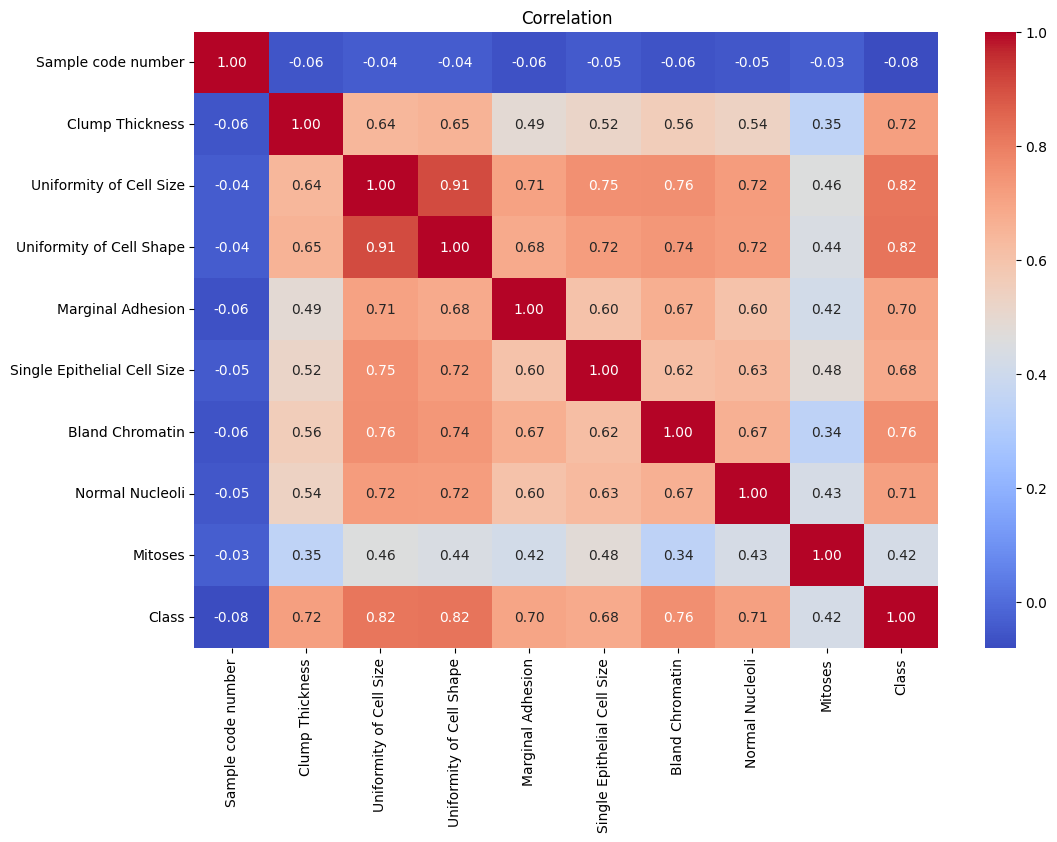

In [60]:
plt.figure(figsize=(12, 8))
sns.heatmap(breast_cancer.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation")
plt.show()

In [61]:
df['Class']=df['Class'].map({2:0,4:1})

In [62]:
df.sample(5)

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
686,536708,1,1,1,1,2,1,1,1,1,0
387,1114570,5,3,3,2,3,1,3,1,1,0
578,695219,1,1,1,1,2,1,2,1,1,0
408,1236837,2,3,2,2,2,2,3,1,1,0
535,1061990,1,1,3,2,2,1,3,1,1,0


In [63]:
x=df.drop(columns=['Class','Bare Nuclei'])
y=df['Class']

In [64]:
scalr=StandardScaler()
x_scalar=scalr.fit_transform(x)

In [65]:
X_train,X_test,y_train,y_test=train_test_split(x_scalar,y,test_size=0.2,random_state=42)

In [66]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [67]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [68]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [69]:
print("Random Forest")
accuracy_randomForest= accuracy_score(y_test, y_pred_rf)
print("Accuracy:",accuracy_randomForest)
precision_rf=precision_score(y_test,y_pred_rf)
print("Precision:",precision_rf)
recall_rf=recall_score(y_test,y_pred_rf)
print("Recall:",recall_rf)
confusion_rf=confusion_matrix(y_test,y_pred_rf)
print("Confusion Matrix:\n",confusion_rf )


Random Forest
Accuracy: 0.9714285714285714
Precision: 0.9361702127659575
Recall: 0.9777777777777777
Confusion Matrix:
 [[92  3]
 [ 1 44]]


In [70]:
print("Support Vector Machine")
accuracy_svm= accuracy_score(y_test, y_pred_svm)
print("Accuracy:",accuracy_svm)
precision_svm=precision_score(y_test,y_pred_svm)
print("Precision:",precision_svm)
recall_svm=recall_score(y_test,y_pred_svm)
print("Recall:",recall_svm)
confusion_svm=confusion_matrix(y_test,y_pred_svm)
print("Confusion Matrix:\n",confusion_svm)

Support Vector Machine
Accuracy: 0.9642857142857143
Precision: 0.9347826086956522
Recall: 0.9555555555555556
Confusion Matrix:
 [[92  3]
 [ 2 43]]


In [71]:
print("Logistic Regression")
accuracy_lr= accuracy_score(y_test, y_pred_lr)
print("Accuracy:",accuracy_lr)
precision_lr=precision_score(y_test,y_pred_lr)
print("Precision:",precision_lr)
recall_lr=recall_score(y_test,y_pred_lr)
print("Recall:",recall_lr)
confusion_lr=confusion_matrix(y_test,y_pred_lr)
print("Confusion Matrix:\n",confusion_lr)

Logistic Regression
Accuracy: 0.95
Precision: 0.9523809523809523
Recall: 0.8888888888888888
Confusion Matrix:
 [[93  2]
 [ 5 40]]
